In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
precios = pd.read_csv('../data/precios_historicos.csv', index_col='Date', parse_dates=True)

tickers = precios.columns.tolist()

print("Tickers en el dataset:", tickers)
print("Forma:", precios.shape)
precios.head()

Tickers en el dataset: ['GGAL', 'MELI', 'SPY', 'YPF']
Forma: (753, 4)


,GGAL,MELI,SPY,YPF
Date,,,,
2023-06-20,14.555366,1197.739990,421.178558,14.54
2023-06-21,15.107026,1210.900024,419.020599,15.45
2023-06-22,14.003702,1241.510010,420.533142,14.73
2023-06-23,14.241343,1226.489990,417.353912,14.79
2023-06-26,14.911825,1155.510010,415.648651,15.40


In [4]:
retornos_diarios = precios.pct_change().dropna()

print("\nRetornos diarios (primeras filas):")
retornos_diarios.head()


Retornos diarios (primeras filas):


,GGAL,MELI,SPY,YPF
Date,,,,
2023-06-21,0.037901,0.010987,-0.005124,0.062586
2023-06-22,-0.073034,0.025279,0.003610,-0.046602
2023-06-23,0.016970,-0.012098,-0.007560,0.004073
2023-06-26,0.047080,-0.057872,-0.004086,0.041244
2023-06-27,-0.045532,0.005694,0.010963,-0.026623


In [5]:
print("\nEstadísticas de retornos diarios:")
retornos_diarios.describe()


Estadísticas de retornos diarios:


,GGAL,MELI,SPY,YPF
count,752.000000,752.000000,752.000000,752.000000
mean,0.002575,0.000720,0.000808,0.002217
std,0.040012,0.024659,0.009615,0.034327
min,-0.235661,-0.162117,-0.058543,-0.153422
25%,-0.020669,-0.011402,-0.003222,-0.016451
50%,0.000089,0.000700,0.001101,0.000835
75%,0.021944,0.014140,0.005827,0.017691
max,0.386960,0.135902,0.105019,0.398882


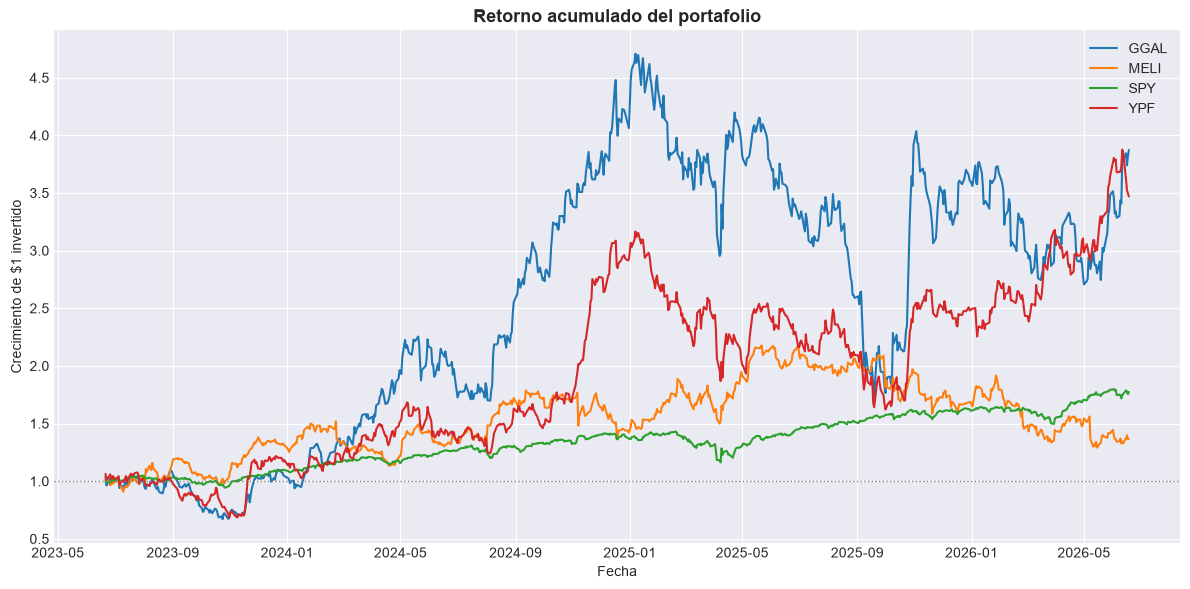


Retorno total acumulado en el período (%):
GGAL    287.28
MELI     36.52
SPY      77.30
YPF     246.97
Name: 2026-06-18 00:00:00, dtype: float64


In [6]:
retorno_acumulado = (1 + retornos_diarios).cumprod()

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(retorno_acumulado.index, retorno_acumulado[ticker], label=ticker, linewidth=1.5)

plt.title('Retorno acumulado del portafolio', fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Crecimiento de $1 invertido')
plt.axhline(y=1, color='gray', linestyle=':', linewidth=1)
plt.legend()
plt.tight_layout()
plt.savefig('../data/retorno_acumulado.png', dpi=150)
plt.show()

# Retorno acumulado final de cada acción (en %)
retorno_total = (retorno_acumulado.iloc[-1] - 1) * 100
print("\nRetorno total acumulado en el período (%):")
print(retorno_total.round(2))


Matriz de correlación:
      GGAL  MELI   SPY   YPF
GGAL  1.00  0.27  0.36  0.73
MELI  0.27  1.00  0.39  0.18
SPY   0.36  0.39  1.00  0.28
YPF   0.73  0.18  0.28  1.00


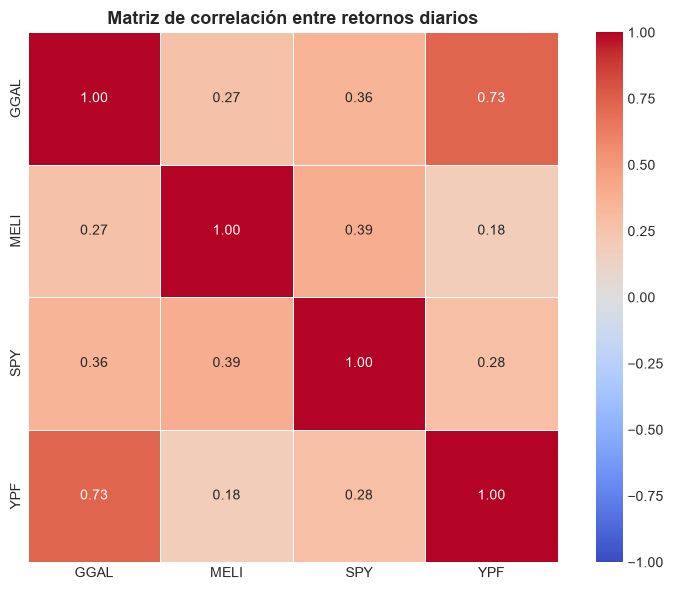

In [7]:
correlacion = retornos_diarios.corr()

print("\nMatriz de correlación:")
print(correlacion.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,        # Muestra el número dentro de cada celda
    fmt='.2f',          # Formato con 2 decimales
    cmap='coolwarm',    # Escala de color: rojo = alta correlación, azul = baja
    vmin=-1, vmax=1,    # Rango fijo para interpretar bien los colores
    square=True,
    linewidths=0.5
)
plt.title('Matriz de correlación entre retornos diarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/matriz_correlacion.png', dpi=150)
plt.show()

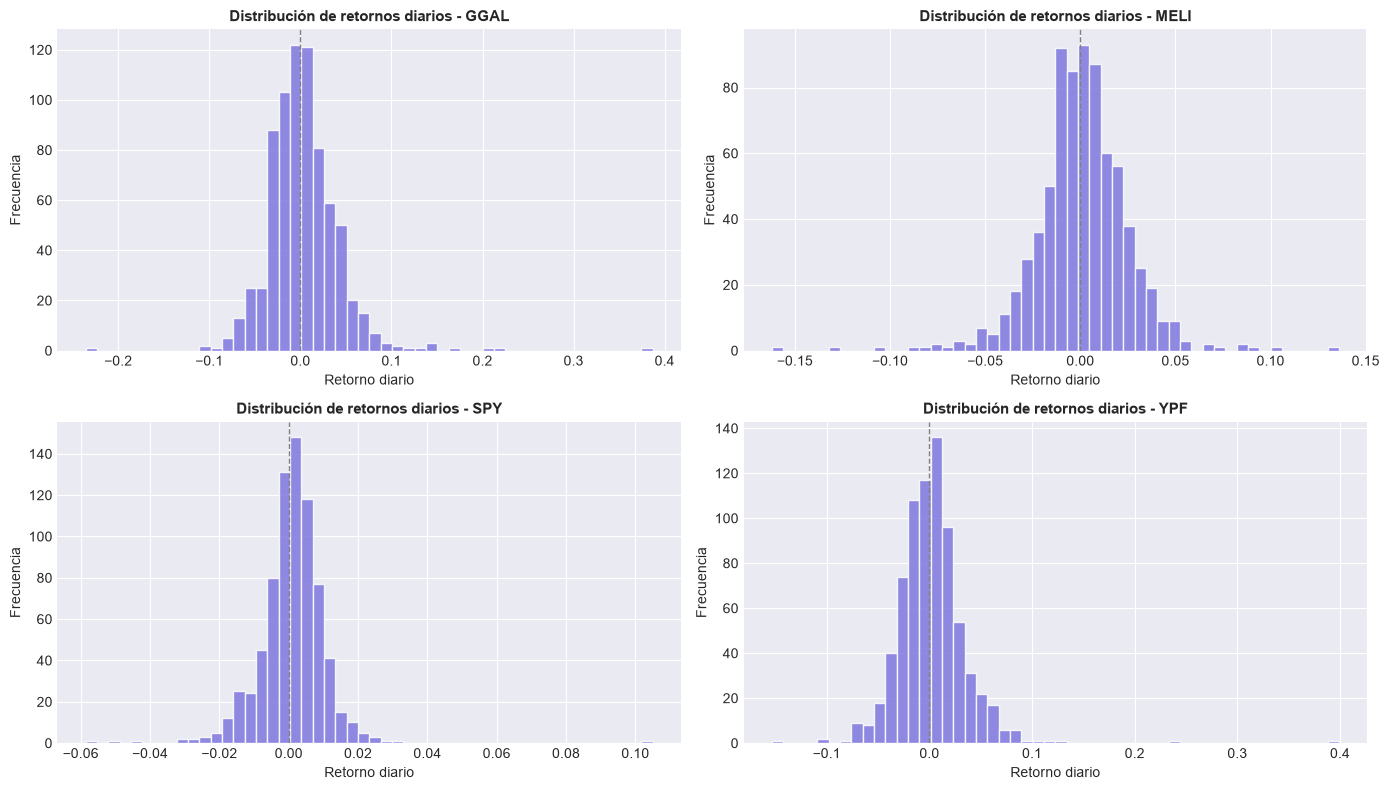


✅ Notebook 2 completo. Listo para calcular métricas de riesgo (Notebook 3).


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].hist(retornos_diarios[ticker], bins=50, color='#7F77DD', edgecolor='white', alpha=0.85)
    axes[i].axvline(x=0, color='gray', linestyle='--', linewidth=1)
    axes[i].set_title(f'Distribución de retornos diarios - {ticker}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Retorno diario')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../data/distribucion_retornos.png', dpi=150)
plt.show()

print("\n✅ Notebook 2 completo. Listo para calcular métricas de riesgo (Notebook 3).")